# Text Mining Final Project

### Group 6
- Kenneth Sunjaya - 2702273315
- William Theodorus Wijaya - 2702227901

# Load library & dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [5]:
df = pd.read_csv('./../data/dataset_crm.csv')

df.head()

,id,code,content,image_url,latitude,longitude,status,category,zone,village,district,city,province,created_at
0,b0906c9a-e3e3-410b-b918-1fa77438563b,JK2401070247,Saya membuat laporan EM231211BDKB tanggal 12 D...,https://s3-jaki.jakarta.go.id/jaki/report/medi...,-6.176120,106.868300,Selesai,Gangguan dan Kebisingan,SATUAN POLISI PAMONG PRAJA KOTA ADM JAKARTA PUSAT,CEMPAKA PUTIH TIMUR,CEMPAKA PUTIH,JAKARTA PUSAT,DKI JAKARTA,2024-01-07T07:10:58.900Z
1,800d8988-3036-4360-b292-77f5ba6bb946,JK2401050479,"Jalan amblas, sudah banyak korban. \nAkibat pe...",https://s3-jaki.jakarta.go.id/jaki/report/medi...,-6.281803,106.771948,Selesai,Jalan,SUDIN SUMBER DAYA AIR JAKARTA SELATAN,PONDOK PINANG,KEBAYORAN LAMA,JAKARTA SELATAN,DKI JAKARTA,2024-01-05T15:27:53.040Z
2,ee1af07a-dc67-4846-9661-ea0c20d1ef08,JK2401100152,"terdapat lubang cukup dalam, atas perhatian da...",https://s3-jaki.jakarta.go.id/jaki/report/medi...,-6.223766,106.823427,Selesai,Jalan,UNIT PERALATAN DAN PERBEKALAN BINA MARGA,KARET KUNINGAN,SETIA BUDI,JAKARTA SELATAN,DKI JAKARTA,2024-01-10T02:38:47.276Z
3,00c83eee-78b5-4749-af46-d17a5e388aa8,JK2401070277,Segera tindak lanjuti masalah hujan lebat dari...,https://s3-jaki.jakarta.go.id/jaki/report/medi...,-6.302330,106.816300,Selesai,Penanganan Banjir,KELURAHAN RAGUNAN,RAGUNAN,PASAR MINGGU,JAKARTA SELATAN,DKI JAKARTA,2024-01-07T08:08:15.210Z
4,ca8a4b6f-21a8-4228-b428-8ad57042775d,JK2401070267,Mohon permohonan peninggian jembatan dan pemba...,https://s3-jaki.jakarta.go.id/jaki/report/medi...,-6.266710,106.832800,Selesai,Jalan,KELURAHAN KALIBATA,KALIBATA,PANCORAN,JAKARTA SELATAN,DKI JAKARTA,2024-01-07T07:38:14.759Z


Dalam penelitian ini, kita hanya akan menggunakan 2 kolom yaitu content dan category, dimana content berisi teks laporan warga sedangkan category merupakan kategori laporan yang diinput secara manual oleh pelapor

In [6]:
df.index = df['id']
df = df[['content', 'category']]

df.head()

,content,category
id,,
b0906c9a-e3e3-410b-b918-1fa77438563b,Saya membuat laporan EM231211BDKB tanggal 12 D...,Gangguan dan Kebisingan
800d8988-3036-4360-b292-77f5ba6bb946,"Jalan amblas, sudah banyak korban. \nAkibat pe...",Jalan
ee1af07a-dc67-4846-9661-ea0c20d1ef08,"terdapat lubang cukup dalam, atas perhatian da...",Jalan
00c83eee-78b5-4749-af46-d17a5e388aa8,Segera tindak lanjuti masalah hujan lebat dari...,Penanganan Banjir
ca8a4b6f-21a8-4228-b428-8ad57042775d,Mohon permohonan peninggian jembatan dan pemba...,Jalan


In [7]:
df['content'].iloc[4]

'Mohon permohonan peninggian jembatan dan pembangunan tanggul pelindung digubris agar tidak ada korban jiwa lagi.'

# Exploratory Data Analysis

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53898 entries, b0906c9a-e3e3-410b-b918-1fa77438563b to e18199f0-79be-42ae-8402-6ed5d108ddc0
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   content   53898 non-null  object
 1   category  53898 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


### Cek jumlah kategori yang terdapat pada laporan

In [9]:
len(df['category'].unique())

68

### Visualisasi WordCloud

Quick check kata - kata yang sering muncul. Kata - kata yang sering muncul memiliki ukuran yang cenderung lebih besar pada plot WordCloud

In [10]:
from wordcloud import WordCloud

text_combined = " ".join(s for s in df['content']).lower()

In [11]:
wc = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    min_font_size=10,
    max_font_size=150,
    colormap='viridis',
    random_state=42
).generate(text_combined)

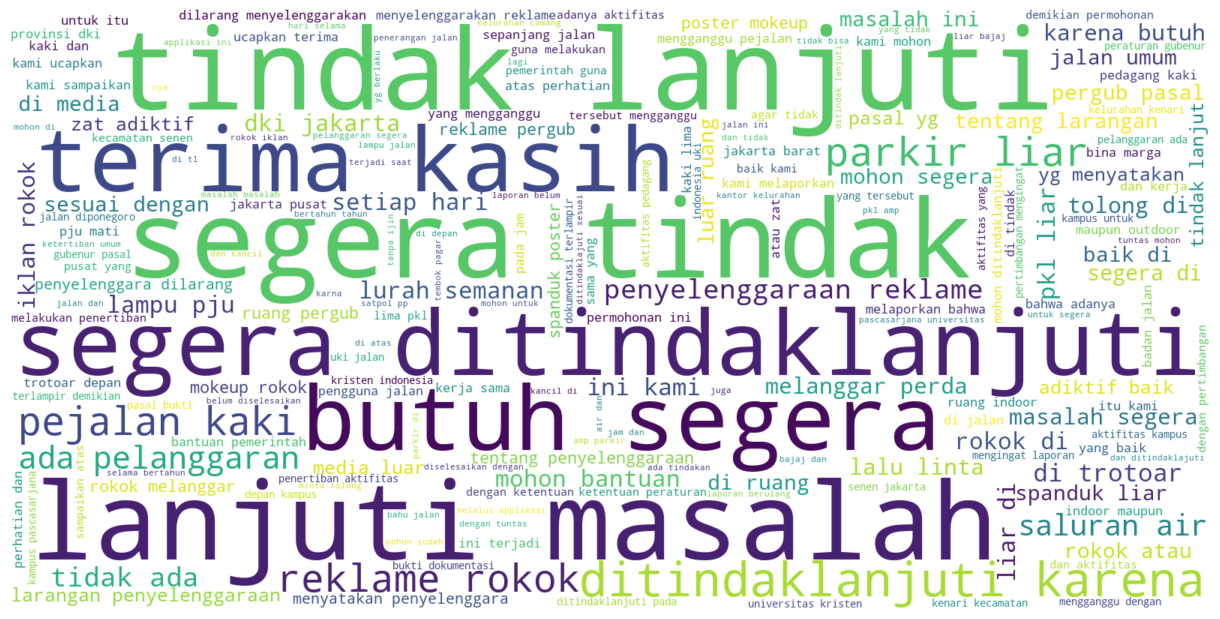

In [12]:
plt.figure(figsize=(12, 6), facecolor=None)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

### Cek Copy-paste Spammer
Cek duplikasi laporan.

In [13]:
df['content'].duplicated().sum()

13234

In [14]:
df[df['content'].duplicated()].head()

,content,category
id,,
96f3308d-59f6-4297-ad8c-dda0218d7553,"kabel internet menjuntai dan berantakan, tolon...",Jaringan Listrik
4d6f9bbe-3050-4eae-ba97-a1348867b780,"kabel internet menjuntai dan berantakan, tolon...",Jaringan Listrik
34783036-df1d-4184-b84f-7b50a6ab3a03,"kabel internet menjuntai dan berantakan, tolon...",Jaringan Listrik
ca536f86-0af9-43e3-878c-668386791b52,"kabel internet menjuntai dan berantakan, tolon...",Jaringan Listrik
8516b374-2b72-4d5e-b981-b7589e255ba3,PKL liar menggunakan fasum untuk berdagang\n\n...,PKL Liar


### Cek Distribusi Data

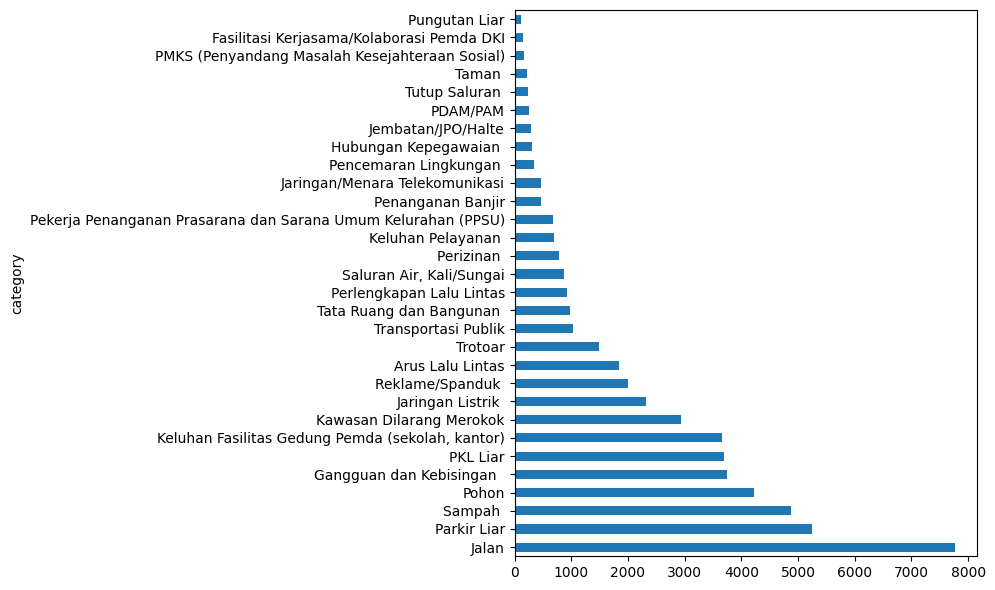

In [16]:
plt.figure(figsize=(10, 6))
df['category'].value_counts().head(30).plot(kind='barh')
plt.tight_layout()
plt.show()

Disini kita dapat melihat bahwa distribusi kategori cenderung imbalance, sehingga ketika kita menggunakan metode supervised learning untuk menggenerate label based on text, model akan cenderung bias ke arah label mayoritas. Oleh karena itu, perlu approach yang lebih efektif untuk handling bias ini, di sini kita akan menggunakan metode unsupervised learning untuk menggenerate label bersamaan dengan hidden sub-topic based on text laporan yang dibuat pada kolom 'content'.

### Noise Analysis

Cek distribusi jumlah kata

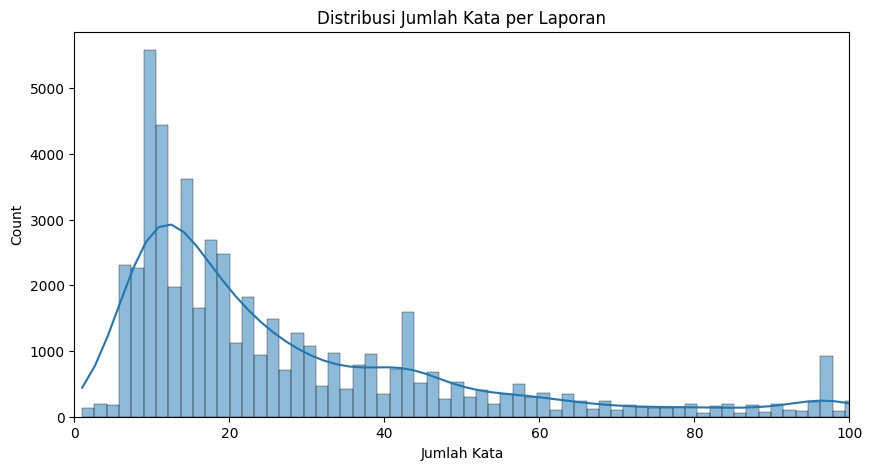

In [17]:
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], kde=True)
plt.title('Distribusi Jumlah Kata per Laporan')
plt.xlabel('Jumlah Kata')
plt.xlim(0, 100)
plt.show()

### Summary Statistics Word Count

In [18]:
df['word_count'].describe().T

count    53898.000000
mean        33.756373
std         37.195414
min          1.000000
25%         12.000000
50%         20.000000
75%         42.000000
max        328.000000
Name: word_count, dtype: float64

Berdasarkan statistik jumlah kata, laporan warga memiliki panjang rata-rata sekitar 34 kata dengan median 20 kata, menunjukkan bahwa sebagian besar laporan bersifat singkat hingga menengah. Namun, terdapat variasi yang cukup besar, mulai dari laporan sangat pendek (1 kata) hingga laporan panjang dengan lebih dari 300 kata, yang berpotensi memengaruhi kualitas clustering dan pelabelan topik.

### Cek Laporan yang Hanya Mengandung 1 Kata

In [19]:
df[df['word_count'] == 1]['content']

id
0afe224b-40bd-4be6-94d9-376385d23c48    Padam............................................
38db9e7a-aa9a-4b16-b393-4ead509ff083    Amblazzzzzzzzzz..................................
f21dfe10-be87-4f34-be06-780789f012a1    corli............................................
096b8c30-3ebf-4c9a-8917-4f8e115b8f82                                              #sampah
a7ea39ae-0248-4603-8968-bc26be46c3f7    ftijjhhdswehjkklluewawwyjjfdswwfghuuuuijjkkkkk...
85560c54-3ecc-48d1-9422-646a9e1ead06    sampahhhhhh......................................
33eda650-90e6-4b35-b5ac-747d5d6c5b8e    ghsiiejdjdjdjdjdjdkdkddkhshsjsjakasklssusjjsnx...
c170d72a-03de-4a31-af06-c717eb108284    odbdidfnrkgkggjfksjsbsvwuabsoaxvheekssnsjsisna...
2e356bcd-64e4-4f49-825b-9085269f6278    vfhhhderghhgrethheethhheerrthxcjjnvxwsshjnbsss...
adb3fe5f-e70e-4142-86b1-873c70d11533    xvhcdbbbvxcbnhfzvnhtsBbgxzbndBBBasddghfssjjjdS...
5f0ed044-0c7e-42a4-9c63-be8b21f0d7c4    parlinap..............................,,,,.......
889427b

Di sini, kita dapat melihat bahwa terdapat beberapa laporan yang hanya mengandung 1 kata saja. Laporan ini wajib dihilangkan karena tidak informatif dan akan tidak memiliki konteks semantik

# Data Preprocessing

In [20]:
%%capture

!pip install Sastrawi

In [21]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('words')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

### Hilangkan bahasa asing selain bahasa indonesia, seperti karakter bahasa jepang, mandrarin, dan korea

In [22]:
def contains_foreign_language(text):
    # Jepang: Hiragana, Katakana
    if re.search(r'[\u3040-\u30ff]', text):
        return True
    
    # Mandarin (Han)
    if re.search(r'[\u4e00-\u9fff]', text):
        return True
    
    # Korea (Hangul)
    if re.search(r'[\uac00-\ud7af]', text):
        return True
    
    return False

In [23]:
df['has_foreign_lang'] = df['content'].apply(contains_foreign_language)
df = df[~df['has_foreign_lang']]
df = df.drop(columns=['has_foreign_lang'])

### Text Cleaning untuk Persiapan Fine-Tuning IndoBERT

In [24]:
def clean_text_for_bert(text):
    text = str(text)

    # Boleh lowercase, IndoBERT p1 uncased (umumnya aman)
    text = text.lower()


    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Hapus markdown bold & italic
    text = re.sub(r'\*\*(.*?)\*\*', r'\1', text)
    text = re.sub(r'\*(.*?)\*', r'\1', text)
    text = re.sub(r'__(.*?)__', r'\1', text)
    text = re.sub(r'_(.*?)_', r'\1', text)
    
    # Hapus Mentions & Hashtags (username, tag)
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # Hapus karakter yang benar-benar aneh (emoji dsb)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [25]:
df['clean_content'] = df['content'].apply(clean_text_for_bert)

### Bandingkan teks sebelum dan setelah cleaning

In [26]:
for i in range(1, 5+1):
  print("Uncleaned Text:")
  print(df['content'][i])

  print("Cleaned Text:")
  print(df['clean_content'][i])

  print("\n")

Uncleaned Text:
Jalan amblas, sudah banyak korban. 
Akibat pekerjaan gorong-gorong kerjanya sembarangan
Cleaned Text:
jalan amblas, sudah banyak korban. akibat pekerjaan gorong-gorong kerjanya sembarangan


Uncleaned Text:
terdapat lubang cukup dalam, atas perhatian dan perbaikannya saya ucapkan terima kasih
Cleaned Text:
terdapat lubang cukup dalam, atas perhatian dan perbaikannya saya ucapkan terima kasih


Uncleaned Text:
Segera tindak lanjuti masalah hujan lebat dari jam 12.00 wib  hingga 14.00 wib menyebabkan jalanan langsung banjir dibawah lutut orang dewasa.
Cleaned Text:
segera tindak lanjuti masalah hujan lebat dari jam 12.00 wib hingga 14.00 wib menyebabkan jalanan langsung banjir dibawah lutut orang dewasa.


Uncleaned Text:
Mohon permohonan peninggian jembatan dan pembangunan tanggul pelindung digubris agar tidak ada korban jiwa lagi.
Cleaned Text:
mohon permohonan peninggian jembatan dan pembangunan tanggul pelindung digubris agar tidak ada korban jiwa lagi.


Uncleaned Te

In [27]:
df['content'] = df['clean_content']

### Delete Copy-Paste Spammer
Hal ini bertujuan untuk menghilangkan konten duplikat yang biasanya disebabkan karena kesalahan sistem atau pelapor melaporkan kejadian secara berulang - ulang (secara psikologis, mereka ingin peluang laporan mereka dibaca dan ditindaklanjuti lebih tinggi)

In [28]:
initial_count = len(df)
df = df.drop_duplicates(subset=['clean_content'])

In [29]:
df['content'].duplicated().sum()

0

### Delete Laporan Warga yang Memiliki Jumlah Kata dibawah 4.
Laporan - laporan seperti ini dianggap tidak informatif dan hanya akan menjadi noise ketika proses training

In [30]:
df = df[df['word_count'] >= 4].copy()

In [31]:
df['word_count'].describe()

count    40111.000000
mean        29.575129
std         32.363224
min          4.000000
25%         12.000000
50%         19.000000
75%         34.000000
max        328.000000
Name: word_count, dtype: float64

In [32]:
df.isna().sum()

content          0
category         0
word_count       0
clean_content    0
dtype: int64

In [33]:
df = df.dropna(subset=['content'])

df['content'] = df['content'].astype(str)

df = df[df['content'].str.strip() != ""]

In [34]:
df.columns

Index(['content', 'category', 'word_count', 'clean_content'], dtype='object')

Save ke .csv supaya tidak perlu cleaning ulang jika ingin re-training notebook.

In [35]:
df = df[['content', 'category']]

df.to_csv('cleaned_dataset.csv', index=False)

### Final Results on Cleaned Dataset

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40111 entries, b0906c9a-e3e3-410b-b918-1fa77438563b to e18199f0-79be-42ae-8402-6ed5d108ddc0
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   content   40111 non-null  object
 1   category  40111 non-null  object
dtypes: object(2)
memory usage: 1.9+ MB


Setelah dilakukan filtering dan cleaning, jumlah data laporan berkurang dari 53898 menjadi hanya 40111 baris.

# Fine-Tuning (IndoBERT)

In [37]:
%%capture

!pip install sentence-transformers

In [38]:
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, models, losses, datasets
import gc
import os

# biar ga diminta Login pas Fine Tuning
os.environ["WANDB_MODE"] = "disabled"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Memastikan GPU memory cache kosong, agar menghindari masalah OOM (Out of Memory) saat training

In [39]:
gc.collect()
torch.cuda.empty_cache()

Di sini kita memastikan bahwa device yang digunakan adalah GPU (CUDA) jika tersedia GPU Nvidia. Hal ini dikarenakan training menggunakan GPU dapat dilakukan dengan jauh lebih cepat karena GPU memiliki CUDA Cores (bisa berjumlah ribuan) yang sangat banyak dibanding core CPU yang biasanya hanya 4-8 cores saja. Dalam task seperti ini, GPU unggul karena pemrosesan paralel lebih diutamakan terutama pada model - model berbasis transformer seperti IndoBERT. Namun tetap disediakan alternatif fallback yaitu CPU jika GPU tidak tersedia

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Reload cleaned csv

In [41]:
df = pd.read_csv('cleaned_dataset.csv')

df.head()

,content,category
0,saya membuat laporan em231211bdkb tanggal 12 d...,Gangguan dan Kebisingan
1,"jalan amblas, sudah banyak korban. akibat peke...",Jalan
2,"terdapat lubang cukup dalam, atas perhatian da...",Jalan
3,segera tindak lanjuti masalah hujan lebat dari...,Penanganan Banjir
4,mohon permohonan peninggian jembatan dan pemba...,Jalan


In [42]:
X = df['content'].tolist()

### Model Training

Metode yang dipake itu TSDAE (Transformer-based Sequential Denoising Auto-Encoder) buat ngelatih IndoBERT buat ngehasilin contextual embedding yang lebih better.

Denoising AutoEncoder (Model belajar menebak kalimat asli dari kalimat yang dirusak dengan diberi noise)
Ini contoh metode fine-tuning dengan tujuan supaya model kita dapat mengubah text kita ke vector embedding yang benar-benar merepresentasikan text tersebut.

- Load Model (IndoBERT)

In [43]:
word_embedding_model = models.Transformer('indobenchmark/indobert-base-p1', max_seq_length=128)

- Menambahkan Pooling Layer untuk mengubah list of vectors jadi vectors (mean vectors)

In [ ]:
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())

- Gabungkan keduanya menjadi SentenceTransformer

In [ ]:
model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

- Membuat training data dengan memberi noise

In [46]:
train_dataset = datasets.DenoisingAutoEncoderDataset(X)

- Konversi ke bentuk DataLoader

In [47]:
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

- Specify Loss Function: TSDAE menggunakan DenoisingAutoEncoderLoss

In [48]:
train_loss = losses.DenoisingAutoEncoderLoss(
    model,
    tie_encoder_decoder=True
)

Some weights of BertLMHeadModel were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'encoder.layer.0.crossattention.output.LayerNorm.bias', 'encoder.layer.0.crossattention.output.LayerNorm.weight', 'encoder.layer.0.crossattention.output.dense.bias', 'encoder.layer.0.crossattention.output.dense.weight', 'encoder.layer.0.crossattention.self.key.bias', 'encoder.layer.0.crossattention.self.key.weight', 'encoder.layer.0.crossattention.self.query.bias', 'encoder.layer.0.crossattention.self.query.weight', 'encoder.layer.0.crossattention.self.value.bias', 'encoder.layer.0.crossattention.self.value.weight', 'encoder.layer.1.crossattention.output.LayerNorm.bias', 'encoder.layer.1.crossattention.output.LayerNorm.weig

- Memulai Fine-Tuning (Training ulang Pretrained IndoBERT Model dengan menggunakan dataset kita)

In [ ]:
history = model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=10,
    scheduler='warmupcosine',
    warmup_steps=int(len(train_dataloader) * 5 * 0.1),
    optimizer_params={'lr': 2e-5},
    weight_decay=0,
    max_grad_norm=1.0,
    show_progress_bar=True,
    use_amp=True
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

  0%|          | 0/50140 [00:00<?, ?it/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


{'loss': 8.1943, 'grad_norm': 5.800994873046875, 'learning_rate': 3.988831272437176e-06, 'epoch': 0.1}
{'loss': 6.6035, 'grad_norm': 6.625636100769043, 'learning_rate': 7.977662544874353e-06, 'epoch': 0.2}
{'loss': 5.8366, 'grad_norm': 6.914577484130859, 'learning_rate': 1.1966493817311529e-05, 'epoch': 0.3}
{'loss': 5.3303, 'grad_norm': 6.121724605560303, 'learning_rate': 1.5955325089748705e-05, 'epoch': 0.4}
{'loss': 4.9473, 'grad_norm': 5.5380377769470215, 'learning_rate': 1.994415636218588e-05, 'epoch': 0.5}
{'loss': 4.7227, 'grad_norm': 5.742269039154053, 'learning_rate': 1.9994711995594537e-05, 'epoch': 0.6}
{'loss': 4.527, 'grad_norm': 5.351568222045898, 'learning_rate': 1.997855236342406e-05, 'epoch': 0.7}
{'loss': 4.3673, 'grad_norm': 5.076127052307129, 'learning_rate': 1.995153761647354e-05, 'epoch': 0.8}
{'loss': 4.3166, 'grad_norm': 6.5674662590026855, 'learning_rate': 1.991369714259086e-05, 'epoch': 0.9}
{'loss': 4.1571, 'grad_norm': 5.524429798126221, 'learning_rate': 1.9

Model IndoBERT dilakukan fine-tuning menggunakan pendekatan unsupervised Denoising Autoencoder selama 10 epoch untuk menyesuaikan representasi embedding dengan karakteristik laporan warga. Selama proses pelatihan, nilai loss menunjukkan tren penurunan yang konsisten dari sekitar 8.19 di awal hingga mendekati 2.0 pada akhir training, menandakan bahwa model semakin mampu merekonstruksi dan memahami struktur semantik teks domain laporan warga. Penggunaan warmup cosine scheduler dan learning rate yang menurun secara bertahap membantu menjaga stabilitas pelatihan serta mencegah overfitting, sehingga embedding hasil fine-tuning lebih representatif untuk tahap clustering selanjutnya.

# Text Representation Transformation

In [50]:
embeddings = model.encode(
    X,
    batch_size=32,
    show_progress_bar=False,
    device=device,
    convert_to_numpy=True,
    normalize_embeddings=True
)

#### Simpan hasil embedding ke dalam vektor .npy. Hal ini bertujuan agar kita tidak perlu retrain model IndoBERT setiap kali melakukan eksperimen

In [ ]:
os.makedirs('output', exist_ok=True)

np.save('output/embeddings_indobert.npy', embeddings)
df.to_csv('output/metadata_laporan.csv', index=False)

model.save('output/trained_indobert')

In [52]:
!zip -r model_indobert.zip output/trained_indobert

updating: output/trained_indobert/ (260 bytes security) (stored 0%)
updating: output/trained_indobert/1_Pooling/ (260 bytes security) (stored 0%)
updating: output/trained_indobert/1_Pooling/config.json (172 bytes security) (deflated 59%)
updating: output/trained_indobert/config.json (172 bytes security) (deflated 57%)
updating: output/trained_indobert/config_sentence_transformers.json (172 bytes security) (deflated 42%)
updating: output/trained_indobert/model.safetensors (172 bytes security) (deflated 7%)
updating: output/trained_indobert/modules.json (172 bytes security) (deflated 55%)
updating: output/trained_indobert/README.md (172 bytes security) (deflated 65%)
updating: output/trained_indobert/sentence_bert_config.json (172 bytes security) (deflated 10%)
updating: output/trained_indobert/special_tokens_map.json (172 bytes security) (deflated 43%)
updating: output/trained_indobert/tokenizer.json (172 bytes security) (deflated 71%)
updating: output/trained_indobert/tokenizer_config.

### Load embeddings dari output/embeddings_indobert.npy

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('words')

import networkx as nx
import community.community_louvain as community_louvain

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Kenneth\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


### Data & Model Reloading

In [54]:
# Load pre-trained embeddings (skip fine-tuning if already done)
embeddings = np.load('output/embeddings_indobert.npy')
df = pd.read_csv('output/metadata_laporan.csv')

print(f"Loaded embeddings shape: {embeddings.shape}")
print(f"Loaded dataframe shape: {df.shape}")
df.head()

Loaded embeddings shape: (40111, 768)
Loaded dataframe shape: (40111, 2)


,content,category
0,saya membuat laporan em231211bdkb tanggal 12 d...,Gangguan dan Kebisingan
1,"jalan amblas, sudah banyak korban. akibat peke...",Jalan
2,"terdapat lubang cukup dalam, atas perhatian da...",Jalan
3,segera tindak lanjuti masalah hujan lebat dari...,Penanganan Banjir
4,mohon permohonan peninggian jembatan dan pemba...,Jalan


# Graph Construction

In [ ]:
%%capture

!pip install python-louvain networkx

### k-NN Parameter

Pada k-NN, setiap node akan terhubung dengan k tetangga terdekat berdasarkan cosine similarity. Ini lebih robust daripada hanya menggunakan threshold cosine similarity karena setiap node pasti punya koneksi. Kita set `k = 10` yang berarti setiap node akan terhubung ke 10 tetangga terdekatnya berdasarkan skor cosine similarity. Setelah kami mencoba beberapa nilai parameter k (5, 10, 15, 20, 25), didapatkan bahwa nilai k = 10 merupakan nilai yang paling optimal untuk graph construction dengan nilai modularitas tertinggi

In [56]:
k = 10  

### Data Preparation

In [ ]:
# Reset index agar cocok dengan partition keys
df = df.reset_index(drop=True)

num_nodes = embeddings.shape[0]
print("Jumlah data:", num_nodes)

Jumlah data: 40111


### k-NN Graph Construction dengan 10 NearestNeighbors

In [ ]:
# NearestNeighbors dengan cosine similarity
nn = NearestNeighbors(
    n_neighbors=k + 1,   # Harus + 1 karena nanti ada dirinya sendiri
    metric='cosine',
    n_jobs=-1
)
nn.fit(embeddings)

distances, indices = nn.kneighbors(embeddings, return_distance=True)

# Buat graph
G = nx.Graph()
G.add_nodes_from(range(num_nodes))

for i in tqdm(range(num_nodes), desc="Building k-NN graph"):
    # Skip index 0 (diri sendiri), ambil 1..k
    neigh_idx = indices[i, 1:]
    neigh_dist = distances[i, 1:]
    
    for j, dist in zip(neigh_idx, neigh_dist):
        # Cosine similarity = 1 - cosine distance
        sim = 1.0 - float(dist)
        
        # Untuk undirected graph, hindari duplicate edge
        if i < j:
            G.add_edge(i, j, weight=sim)

Building k-NN graph:   0%|          | 0/40111 [00:00<?, ?it/s]

### Final Graph

In [59]:
print(f"Jumlah Nodes: {G.number_of_nodes()}")
print(f"Jumlah Edges: {G.number_of_edges()}")

Jumlah Nodes: 40111
Jumlah Edges: 198952


# Louvain Algorithm

Clustering nodes yang ada di graph. Clustering dilakukan terhadap seberapa rapat node-node saling terhubung di dalam cluster dibanding antar-cluster.

- **Node yang banyak edge similarity tinggi** akan **masuk cluster yang sama**.

$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

### Louvain Clustering di k-NN Graph

In [61]:
partition = community_louvain.best_partition(
    G,
    resolution=1.0,
    random_state=42
)

# Hitung modularity (untuk evaluasi kualitas clustering)
modularity = community_louvain.modularity(partition, G)
print(f"Modularity: {modularity:.4f}")

Modularity: 0.8226


Nilai modularity sebesar 0.8226 menunjukkan bahwa hasil clustering memiliki kualitas yang sangat baik. Skor ini menandakan bahwa koneksi antar laporan lebih padat di dalam cluster dibandingkan dengan koneksi ke cluster lain, sehingga struktur cluster yang terbentuk bersifat jelas dan terpisah dengan baik.

### Mapping (Ubah jadi cluster-cluster)

In [ ]:
df['cluster'] = df.index.map(partition)

print(f"Jumlah cluster unik: {df['cluster'].nunique()}")

Jumlah cluster unik: 289


### Save ke .csv agar dapat digunakan lagi untuk eksperimen berikutnya

In [63]:
output_file = 'output/laporan_warga_clustered_knn_louvain.csv'
df.to_csv(output_file, index=False)
print(f"Saved to: {output_file}")

Saved to: output/laporan_warga_clustered_knn_louvain.csv


# Topic Extraction (TF-IDF)

### Text cleaning sebelum topic extraction dengan TF-IDF
Metode text cleaning yang dilakukan di sini beda dengan text cleaning sebelum Fine-Tuning. Pada cleaning kali ini kita melakukan cleaning dengan lebih agresif seperti stemming, removing stop words, normalisasi slang words.

In [122]:
df = pd.read_csv('output/laporan_warga_clustered_knn_louvain.csv')

In [123]:
list_stopwords = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()

### Mapping slang words yang sering dan berpotensi muncul di laporan

In [124]:
slang_dict = {
    "gak": "tidak",
    "ga": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "bkn": "bukan",
    "sy": "saya",
    "nih": "ini",
    "nihh": "ini",
    "tuh": "itu",
    "yg": "yang",
    "jgn": "jangan",
    "sdh": "sudah",
    "udh": "sudah",
    "uda": "sudah",
    "blm": "belum",
    "hrs": "harus",
    "jd": "jadi",
    "jdi": "jadi",
    "dpt": "dapat",
    "dapet": "dapat",
    "kmrn": "kemarin",
    "kemaren": "kemarin",
    "ntar": "nanti",
    "nnti": "nanti",
    "dl": "dulu",
    "lg": "lagi",
    "lgi": "lagi",
    "cpt": "cepat",
    "pkl": "pukul",
    "dgn": "dengan",
    "dg": "dengan",
    "dlm": "dalam",
    "dr": "dari",
    "utk": "untuk",
    "sbg": "sebagai",
    "sm": "sama",
    "pd": "pada",
    "klo": "kalau",
    "klw": "kalau",
    "tp": "tapi",
    "krn": "karena",
    "jk": "jika",
    "bgt": "banget",
    "sgt": "sangat",
    "psti": "pasti",
    "bnr": "benar",
    "bener": "benar",
    "mls": "malas",
    "kesel": "kesal",
    "cape": "lelah",
    "capek": "lelah",
    "syg": "sayang",
    "bbrp": "beberapa",
    "brp": "berapa",
    "smw": "semua",
    "msh": "masih",
    "skli": "sekali",
    "cmn": "cuma",
    "jl": "jalan",
    "tdk": "tidak",
    "td": "tadi",
    "tsb": "tersebut",
    "drpd": "daripada",
    "kpd": "kepada",
    "sblm": "sebelum",
    "tks": "terima kasih",
    "trmksh": "terima kasih",
    "mksh": "makasih",
    "mks": "makasih",
    "thx": "makasih",
    "plg": "pulang",
    "brg": "barang",
    "trims": "terima kasih",
    "dlu": "dulu",
    "sblmnya": "sebelumnya",
    "tl": "tolong",
    "sp": "siapa",
    "gk": "tidak",
    "tau": "tahu",
    "bs": "bisa",
    "dg": "dengan",
    "sda": "sudah",
    "iy": "iya",
    "iyaaa": "iya",
    "yaa": "ya",
    "yuk": "ayo",
    "aja": "saja",
    "aj": "saja",
    "ajaah": "saja",
    "mks": "makasih",
    "mksh": "makasih",
    "thx": "makasih",
    "trims": "terima kasih",
    "tlg": "tolong",
    "gpp": "tidak apa apa",
    "gapapa": "tidak apa apa",
    "si": "sih",
    "smpe": "sampai",
    "smoga": "semoga",
    "trs": "terus",
    "trus": "terus",
    "ngapain": "mengapa",
    "knp": "kenapa",
    "kpn": "kapan",
    "dmn": "dimana",
    "gmn": "bagaimana",
    "bgmn": "bagaimana",
    "hrsnya": "harusnya",
    "hrsny": "harusnya",
    "shrsnya": "seharusnya",
    "shrsny": "seharusnya",
    "scptny": "secepatnya",
    "scptnya": "secepatnya",
    "org": "orang",
    "ad": "ada",
    "no": "nomor",
    "jkt": "jakarta",
    "pmlg": "pemalang",
    "bdg": "bandung",
    "sby": "surabaya",
    "rt": "rt",
    "rw": "rw",
    "kel": "kelurahan",
    "kec": "kecamatan",
    "jl": "jalan",
    "jln": "jalan",
    "pemprov": "pemerintah provinsi",
    "tps": "tempat pembuangan sampah",
    "pju": "penerangan jalan umum",
    "tkp": "tempat kejadian perkara",
    "klontong": "kelontong",
}

#### Define domain specific stopwords, lalu dikombinasikan dengan preloaded stopwords Bahasa Indonesia

In [125]:
domain_specific_stopwords = [
    "rt", "rw", "kel", "kec", "pemprov", "pmlg", "bdg", "sby", "tps", "pju", "si", "itu", "ini", "ya", "dll", "dst", "sp", "sih", "aja", "aj", "nya", "tl", "al", "tks", "quot", "dna", "ya", "pkl", "no", "wib", "cm"
]

list_stopwords = list_stopwords.union(set(domain_specific_stopwords))

In [ ]:
import emoji
def clean_text_for_labeling(text):
    text = str(text).lower()

    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Hapus Mentions & Hashtags
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # Hapus emoji yang mungkin tersisa
    text = emoji.replace_emoji(text, replace='')

    # Hapus angka & simbol non-huruf
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    cleaned_tokens = []
    tokens = word_tokenize(text)

    for word in tokens:
        word = re.sub(r'(.)\1{2,}', r'\1', word)
        if word in slang_dict:
            word = slang_dict[word]

        # Stopwords removal
        if word in list_stopwords:
            continue

        # Stemming
        stemmed_word = stemmer.stem(word)
        cleaned_tokens.append(stemmed_word)
    
    return " ".join(cleaned_tokens)


In [127]:
tqdm.pandas(desc="Cleaning content for labeling")
df['content_for_labeling'] = df['content'].progress_apply(clean_text_for_labeling)

Cleaning content for labeling:   0%|          | 0/40111 [00:00<?, ?it/s]

### Data Grouping (by Cluster)

In [128]:
docs_per_class = df.groupby(['cluster'], as_index=False).agg({'content_for_labeling': ' '.join})

In [129]:
docs_per_class.head()

,cluster,content_for_labeling
0,0,lapor em bdkb tanggal desember em c j tanggal ...
1,1,jalan amblas korban akibat kerja gorong gorong...
2,2,lubang perhati baik ucap terima kasih mohon to...
3,3,tindak lanjut hujan lebat jam sebab jalan lang...
4,4,tutup got hancur tolong baik butuh ditindaklan...


### TF-IDF (Term Frequency-Inverse Document Frequency)

In [ ]:
id_stop_words = list(list_stopwords)

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=id_stop_words,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(docs_per_class['content_for_labeling'])
feature_names = tfidf_vectorizer.get_feature_names_out()

#### Ekstrak top 5 kata yang paling sering muncul di setiap clusternya

Top 5 kata ini nantinya akan menjadi topik label baru yang merepresentasikan isi laporan di setiap clusternya

In [ ]:
top_n_words = 5
cluster_labels = {}

for i in range(len(docs_per_class)):
    cluster_id = docs_per_class.iloc[i]['cluster']

    row = tfidf_matrix[i].toarray().flatten()
    top_indices = row.argsort()[-top_n_words:][::-1]
    top_features = [feature_names[idx] for idx in top_indices]

    if len(top_features) > 0:
        final_label = top_features
    else:
        continue

    cluster_labels[cluster_id] = final_label

### Mapping (Map topic phrases ke setiap laporan)

In [132]:
df['topic_label'] = df['cluster'].map(cluster_labels)

In [133]:
df.head()

,content,category,cluster,content_for_labeling,topic_label
0,saya membuat laporan em231211bdkb tanggal 12 d...,Gangguan dan Kebisingan,0,lapor em bdkb tanggal desember em c j tanggal ...,"[lapor, ulang, tolong, langgar, selesai]"
1,"jalan amblas, sudah banyak korban. akibat peke...",Jalan,1,jalan amblas korban akibat kerja gorong gorong...,"[jalan, lubang, bahaya, rusak, mohon]"
2,"terdapat lubang cukup dalam, atas perhatian da...",Jalan,2,lubang perhati baik ucap terima kasih,"[selamat, mohon, terima, kasih, bantu]"
3,segera tindak lanjuti masalah hujan lebat dari...,Penanganan Banjir,3,tindak lanjut hujan lebat jam sebab jalan lang...,"[sampah, air, salur, mohon, tindak]"
4,mohon permohonan peninggian jembatan dan pemba...,Jalan,3,mohon mohon tinggi jembatan bangun tanggul lin...,"[sampah, air, salur, mohon, tindak]"


### Save lagi ke .csv

In [134]:
output_file = 'output/final_laporan_warga_labeled.csv'
df.to_csv(output_file, index=False)

## Global C_V Coherence Score

Global C_V Coherence digunakan untuk mengukur kualitas keseluruhan label topik yang dihasilkan dari proses clustering. Nilai ini merefleksikan seberapa sering kata-kata penyusun topik muncul bersama dalam konteks dokumen yang sama, sehingga menunjukkan konsistensi dan keterkaitan semantik antar topik

In [135]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import pandas as pd
import re

texts = []

df = pd.read_csv('output/final_laporan_warga_labeled.csv')

for doc in df['content'].astype(str).str.lower():
    tokens = re.findall(r"[a-z]+", doc)
    texts.append(tokens)

dictionary = Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)

In [136]:
import ast

topics = []

for words in df['topic_label'].dropna():
    if isinstance(words, str):
        words = ast.literal_eval(words) # dari string yg ada di .csv ke list lagi
    if len(words) >= 2:
        topics.append(words)


In [137]:
cm = CoherenceModel(
    topics=topics,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

print("Global C_V Coherence:", cm.get_coherence())

Global C_V Coherence: 0.5995809264037035


Nilai Global C_V Coherence sebesar 0.5996 menunjukkan bahwa topik-topik yang dihasilkan cukup bermakna dan tidak bersifat acak.

## Human Inspection 

Menyiapkan file .csv untuk inspeksi dan analisis human based evaluation. 

Hal - hal yang diperhatikan dalam human based evaluation meliputi: 
- koherensi cluster (apakah laporan dalam suatu cluster memang memiliki konteks yang sama?)
- relevansi label (apakah label merepresentasikan teks jika dibaca oleh manusia?)

In [138]:
df = pd.read_csv('output/laporan_warga_clustered_knn_louvain.csv')
number_of_clusters = df['cluster'].nunique()
print("Jumlah cluster:", number_of_clusters)

Jumlah cluster: 289


In [139]:
cluster_sizes = df['cluster'].value_counts()

# ambil 4 cluster besar, 4 sedang, 2 kecil
large_clusters = cluster_sizes[cluster_sizes >= 80].index[:4].tolist()
medium_clusters = cluster_sizes[(cluster_sizes >= 30) & (cluster_sizes < 80)].index[:4].tolist()
small_clusters = cluster_sizes[cluster_sizes < 30].index[:2].tolist()

selected_clusters = large_clusters + medium_clusters + small_clusters
print(selected_clusters)

print(f"large_clusters: {large_clusters}")
print(f"medium_clusters: {medium_clusters}")
print(f"small_clusters: {small_clusters}")

[10, 11, 3, 1, 24, 46, 52, 43, 41, 31]
large_clusters: [10, 11, 3, 1]
medium_clusters: [24, 46, 52, 43]
small_clusters: [41, 31]


### Ambil 5 random sample dari masing - masing cluster

In [140]:
HUMAN_SAMPLE_PER_CLUSTER = 5

complete_df = pd.read_csv('output/final_laporan_warga_labeled.csv')

human_eval_df = (
    complete_df[complete_df['cluster'].isin(selected_clusters)]
    .groupby('cluster')
    .apply(lambda x: x.sample(min(len(x), HUMAN_SAMPLE_PER_CLUSTER), random_state=42))
    .reset_index(drop=True)
)

human_eval_df = human_eval_df[['cluster', 'content', 'topic_label', 'category']]
human_eval_df

,cluster,content,topic_label,category
0,1,penutup got berlubang dapat membahayakan kenda...,"['jalan', 'lubang', 'bahaya', 'rusak', 'mohon']","Saluran Air, Kali/Sungai"
1,1,"jalan berlubang, bahaya untuk pengendara. apa ...","['jalan', 'lubang', 'bahaya', 'rusak', 'mohon']",Jalan
2,1,penerangan sangat minim perlu ditambahkan lamp...,"['jalan', 'lubang', 'bahaya', 'rusak', 'mohon']","Keluhan Fasilitas Gedung Pemda (sekolah, kantor)"
3,1,tambal dan perbaiki jalan2 mau berlubang agar ...,"['jalan', 'lubang', 'bahaya', 'rusak', 'mohon']",Jalan
4,1,pembangunan pintu keluar masuk pabrik atau gud...,"['jalan', 'lubang', 'bahaya', 'rusak', 'mohon']",Tata Ruang dan Bangunan
5,3,dear pemprov dki mohon bantuannya untuk mengan...,"['sampah', 'air', 'salur', 'mohon', 'tindak']",Sampah
6,3,ini sampah informasi nya sudah di bersihkan te...,"['sampah', 'air', 'salur', 'mohon', 'tindak']",Sampah
7,3,pipa saluran air (limbah) bocor.. sudah coba k...,"['sampah', 'air', 'salur', 'mohon', 'tindak']",Jalan
8,3,di area tempat pemakaman umum tegal alur banya...,"['sampah', 'air', 'salur', 'mohon', 'tindak']",Sampah
9,3,hallo pak ppsu mohon dicukur dibersihkan &amp;...,"['sampah', 'air', 'salur', 'mohon', 'tindak']",Sampah


#### Save ke .csv agar lebih mudah dalam melakukan evaluasi manual

In [141]:
human_eval_df.to_csv(
    "output/human_evaluation_clusters.csv",
    index=False
)

Pipeline ini berhasil mengelompokkan laporan warga berdasarkan kemiripan semantiknya meskipun terdapat variasi bahasa dan gaya penulisan yang tinggi. Fine-tuning **IndoBERT** dengan menggunakan metode Transformer-Based Sequential Denoising Auto-Encoder mampu menghasilkan contextual embedding yang lebih sesuai dengan konteks laporan warga Jakarta, sehingga proses topic discovery dapat menghasilkan topik-topik yang lebih spesifik dan informatif dibandingkan kategori awal yang ada pada website crm.jakarta.go.id. Hasil evaluasi menunjukkan performa yang baik, ditunjukkan oleh nilai **Global C_V** Coherence sebesar **0.5996** dan **Modularity Score** sebesar **0.8226**, yang mengindikasikan bahwa topik yang terbentuk cukup konsisten dan struktur clustering berhasil memisahkan laporan sesuai dengan topiknya. Secara keseluruhan, hasil ini memiliki potensi untuk mendukung sistem pelaporan pemerintah dalam memahami laporan warga secara lebih cepat, terstruktur, dan efisien.

GitHub repository: https://github.com/williamtheodoruswijaya/mteb-auto-labeller.git